# Fig 05: Validation of the P-case: internal variability

In [1]:
import os
os.chdir('/glade/work/fengzhu/Projects/paper-OnlinePDA_CESM/notebooks')
import numpy as np
import xarray as xr
import pyleoclim as pyleo
import x4c
import datetime
print(f'Last update: {datetime.date.today()}')

Last update: 2026-06-12


## Load Data

In [ ]:
case = 'ppe_400ppm'
gmsst = xr.open_dataset(f'../recons/{case}_gmsst.nc')
gmlst = xr.open_dataset(f'../recons/{case}_gmlst.nc')
nino34 = xr.open_dataset(f'../recons/{case}_nino34.nc')

## Plotting

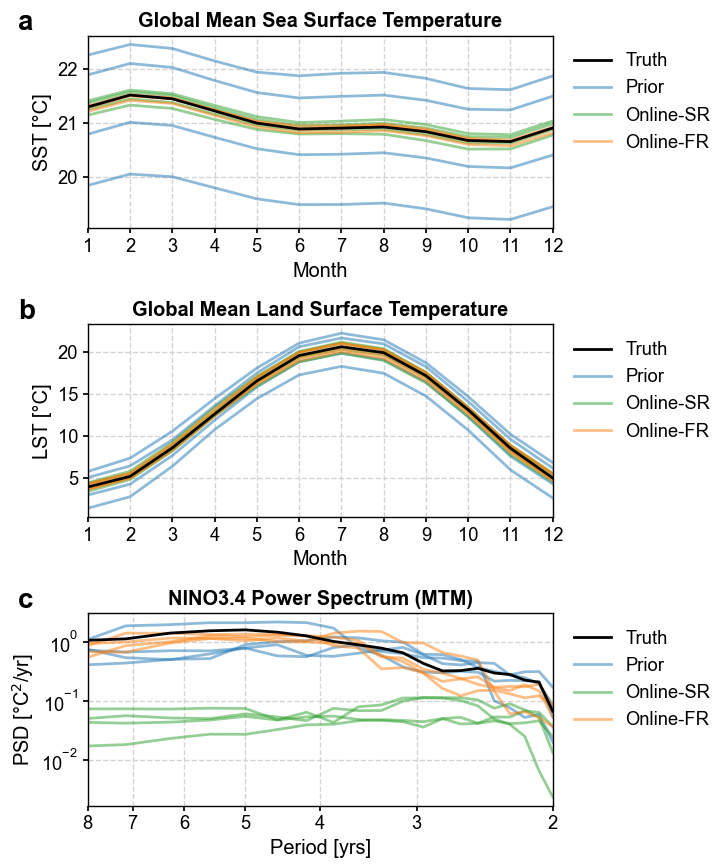

Figure saved at: "../figs/ppe_400ppm_diags.pdf"


In [3]:
x4c.set_style('journal_spines', font_scale=1.2)
ax_loc={
    'gmsst': (0, 0),
    'gmlst': (1, 0),
    'nino34': (2, 0),
}
annotation_kws={n: {'loc_x': -0.15, 'style': ''} for n in ax_loc.keys()}

fig, ax = x4c.visual.subplots(
    figsize=(6, 10), nrow=3, ncol=1, hspace=0.5, wspace=0.2,
    ax_loc=ax_loc,
    annotation=True,
    annotation_separate=True,
    annotation_kws=annotation_kws,
    annotation_skip=['cb_map', 'cb_diff'],
)

clr_dict={
    'Truth': 'k',
    'Prior': 'tab:blue',
    'Offline': 'tab:red',
    'Online-SR': 'tab:green',
    'Online-FR': 'tab:orange',
}

for tag in ['Truth', 'Prior', 'Online-SR', 'Online-FR']:
    label = tag
    da_sst = gmsst[tag]
    da_lst = gmlst[tag]
    zorder = 99 if tag == 'Truth' else 1
    if 'ens' in da_sst.dims:
        for i in range(da_sst.sizes['ens']):
            da_sst.isel(ens=i).x.plot(ax=ax['gmsst'], label=label if i == 0 else None, color=clr_dict[tag], alpha=0.5, title='Global Mean Sea Surface Temperature', zorder=zorder)
            da_lst.isel(ens=i).x.plot(ax=ax['gmlst'], label=label if i == 0 else None, color=clr_dict[tag], alpha=0.5, title='Global Mean Land Surface Temperature', zorder=zorder)
    else:
        da_sst.x.plot(ax=ax['gmsst'], label=label, color=clr_dict[tag], title='Global Mean Sea Surface Temperature', zorder=zorder)
        da_lst.x.plot(ax=ax['gmlst'], label=label, color=clr_dict[tag], title='Global Mean Land Surface Temperature', zorder=zorder)

ax['gmsst'].legend(loc='upper left', bbox_to_anchor=(1.01, 1))
ax['gmlst'].legend(loc='upper left', bbox_to_anchor=(1.01, 1))
ax['gmsst'].set_xlabel('Month')
ax['gmlst'].set_xlabel('Month')
ax['gmsst'].set_xticks(np.arange(1, 13))
ax['gmlst'].set_xticks(np.arange(1, 13))
ax['gmsst'].set_xlim(1, 12)
ax['gmlst'].set_xlim(1, 12)

# Spectral analysis for NINO3.4 using Pyleoclim MTM
def plot_spectrum(ax, x, color, label=None, alpha=1.0, lw=1.5, NW=4, zorder=1):
    """MTM spectral analysis via Pyleoclim. NW: time-half-bandwidth product."""
    x = np.asarray(x).ravel()
    x = x[~np.isnan(x)]
    N = len(x)
    if N < 4:
        return False
    t = np.arange(N, dtype=float)
    ts = pyleo.Series(time=t, value=x, verbose=False)
    psd = ts.spectral(method='mtm', settings={'NW': NW, 'standardize': False}, verbose=False)
    period = 1.0 / psd.frequency
    ax.plot(period, psd.amplitude, color=color, alpha=alpha, lw=lw, label=label, zorder=zorder)
    return True

for tag in ['Truth', 'Prior', 'Online-SR', 'Online-FR']:
    label = tag
    color = clr_dict[tag]
    da = nino34[tag]

    zorder = 99 if tag == 'Truth' else 1
    if 'ens' in da.dims:
        for i in range(da.sizes['ens']):
            ok = plot_spectrum(ax['nino34'], da.isel(ens=i).values, color=color, label=label if (i == 0) else None, alpha=0.5, lw=2, zorder=zorder)
    else:
        plot_spectrum(ax['nino34'], da.values, color=color, label=label, alpha=1, lw=2, zorder=zorder)

ax['nino34'].legend(loc='upper left', bbox_to_anchor=(1.01, 1))
ax['nino34'].set_title('NINO3.4 Power Spectrum (MTM)', weight='bold')
ax['nino34'].set_xlabel('Period [yrs]')
ax['nino34'].set_ylabel(r'PSD [°C$^2$/yr]')
ax['nino34'].set_xscale('log')
ax['nino34'].set_yscale('log')
ax['nino34'].set_xticks([2, 3, 4, 5, 6, 7, 8])
ax['nino34'].set_xticklabels(['2', '3', '4', '5', '6', '7', '8'])
ax['nino34'].set_xlim([8, 2])

for tag in ['gmsst']:
    ax[tag].set_ylabel('SST [°C]')
for tag in ['gmlst']:
    ax[tag].set_ylabel('LST [°C]')

x4c.showfig(fig)
x4c.savefig(fig, f'../figs/{case}_diags.pdf')
